# 04 -- Evaluation

BERT/CNN2D evaluation metrics, the data-grain audit, and SHAP explainability -- all extracted from the real original notebook. Standalone-runnable: loads the already-trained checkpoints from disk rather than requiring 03_Training to run first.

In [ ]:
import os
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "backend" / "app").is_dir() and (candidate / "data").is_dir():
            return candidate
        alt = candidate / "Olist_Marketplace_Platform"
        if (alt / "backend" / "app").is_dir() and (alt / "data").is_dir():
            return alt
    raise RuntimeError("Could not locate the project root above this notebook.")


PROJECT_ROOT = _find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "backend"))
print("Project root:", PROJECT_ROOT)


In [ ]:
# Standalone setup: loads the ALREADY-TRAINED BERT and CNN2D checkpoints from
# disk (no retraining needed to evaluate) and rebuilds the same train/val/test
# split via this project's real, shared functions (backend/app/ml) so the
# extracted evaluation cells below (which report train/val/test metrics) have
# real data to run against.
import pickle
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

from app.ml.preprocessing import build_sentiment_dataframe, remove_duplicate_reviews, split_sentiment_dataset
from app.ml.datasets import encode_texts_for_cnn, build_cnn_dataloader
from app.ml.models import load_fine_tuned_bert, load_cnn2d_model, CNN_MAX_LEN
from app.ml.utils import set_seed, get_device

SEED = 42
set_seed(SEED)
device = get_device()

reviews = pd.read_csv("data/interim/reviews_translated.csv")
sent_df = build_sentiment_dataframe(reviews)
deduped, _ = remove_duplicate_reviews(sent_df)
split = split_sentiment_dataset(deduped, seed=SEED)
X_train, y_train = split.train["text"], split.train["label"]
X_val, y_val = split.val["text"], split.val["label"]
X_test, y_test = split.test["text"], split.test["label"]

model_bert, tokenizer_bert = load_fine_tuned_bert("models/bert_review_sentiment", device=device)


class ReviewSentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts, self.labels = list(texts), list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], int(self.labels[idx])


def make_collate_fn(tokenizer, max_len=128):
    def collate_fn(batch):
        texts, labels = zip(*batch)
        encodings = tokenizer(list(texts), max_length=max_len, padding=True, truncation=True, return_tensors="pt")
        encodings["labels"] = torch.tensor(labels, dtype=torch.long)
        return encodings
    return collate_fn


bert_collate_fn = make_collate_fn(tokenizer_bert)
train_loader_bert = DataLoader(ReviewSentimentDataset(X_train.astype(str).tolist(), y_train.values), batch_size=8, shuffle=False, collate_fn=bert_collate_fn)
val_loader_bert = DataLoader(ReviewSentimentDataset(X_val.astype(str).tolist(), y_val.values), batch_size=8, shuffle=False, collate_fn=bert_collate_fn)
test_loader_bert = DataLoader(ReviewSentimentDataset(X_test.astype(str).tolist(), y_test.values), batch_size=8, shuffle=False, collate_fn=bert_collate_fn)

with open("artifacts/cnn2d_tokenizer.pkl", "rb") as f:
    cnn_tokenizer = pickle.load(f)
model_cnn2d = load_cnn2d_model("models/cnn2d_review_sentiment.pt", device=device)
train_loader_cnn = build_cnn_dataloader(encode_texts_for_cnn(X_train, cnn_tokenizer, max_len=CNN_MAX_LEN), y_train, batch_size=64, shuffle=False)
val_loader_cnn = build_cnn_dataloader(encode_texts_for_cnn(X_val, cnn_tokenizer, max_len=CNN_MAX_LEN), y_val, batch_size=64, shuffle=False)
test_loader_cnn = build_cnn_dataloader(encode_texts_for_cnn(X_test, cnn_tokenizer, max_len=CNN_MAX_LEN), y_test, batch_size=64, shuffle=False)

# Not re-measured in this standalone evaluation pass (no training happens here) --
# only used by the extracted comparison table / training-history plot below.
bert_train_time = float("nan")
cnn2d_train_time = float("nan")
_nan_hist = {"loss": [float("nan")], "accuracy": [float("nan")], "val_loss": [float("nan")], "val_accuracy": [float("nan")]}
history_bert = dict(_nan_hist)
history_cnn2d = dict(_nan_hist)


def run_bert_epoch(model, loader, optimizer=None, scheduler=None):
    """Same helper defined in the original notebook's training cell (§6A) --
    needed here in eval-only mode (optimizer=None) since training isn't
    re-run in this standalone evaluation pass."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                scheduler.step()
            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == batch["labels"]).sum().item()
            total += batch["labels"].size(0)
            total_loss += loss.item() * batch["labels"].size(0)
    return total_loss / total, correct / total


# Same for CNN2D's eval loop -- criterion_cnn/smooth_labels/run_cnn_epoch are
# only defined in the original notebook's CNN2D training cell (§6B.3).
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

_class_weights_arr = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
pos_weight = torch.tensor(_class_weights_arr[1] / _class_weights_arr[0], dtype=torch.float32).to(device)
criterion_cnn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def smooth_labels(y, smoothing=0.1):
    return y * (1.0 - smoothing) + 0.5 * smoothing


def run_cnn_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion_cnn(logits, smooth_labels(y_batch))
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
            total_loss += loss.item() * y_batch.size(0)
    return total_loss / total, correct / total

print(f"Loaded trained BERT + CNN2D from disk. Train/val/test: {len(y_train):,}/{len(y_val):,}/{len(y_test):,}")


====== [3] BERT Model: Evaluation Metrics Summary ======


[+] Classification Report — BERT — TRAINING SET:

              precision    recall  f1-score   support

    Negative       0.95      0.96      0.95      1519
    Positive       0.98      0.98      0.98      3481

    accuracy                           0.97      5000
   macro avg       0.97      0.97      0.97      5000
weighted avg       0.97      0.97      0.97      5000

Additional metrics:
  Accuracy                    : 0.9724
  Precision (macro)           : 0.9657
  Recall (macro)              : 0.9694
  F1 (macro)                  : 0.9675
  ROC-AUC                     : 0.9893
  PR-AUC (Average Precision)  : 0.9950
  MCC                         : 0.9351
------------------------------------------------------------

[+] Classification Report — BERT — VALIDATION SET:

              precision    recall  f1-score   support

    Negative       0.88      0.90      0.89       302
    Positive       0.96      0.95      0.95     

,Dataset Split,Accuracy,Loss
0,Training Set,0.9628,0.1444
1,Validation Set,0.9320,0.2721
2,Testing Set,0.9225,0.3009


,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC,PR-AUC (Average Precision),MCC
TRAINING SET,0.9724,0.9657,0.9694,0.9675,0.9893,0.9950,0.9351
VALIDATION SET,0.9320,0.9170,0.9231,0.9199,0.9722,0.9885,0.8401
TESTING SET,0.9225,0.9013,0.9168,0.9085,0.9698,0.9880,0.8180


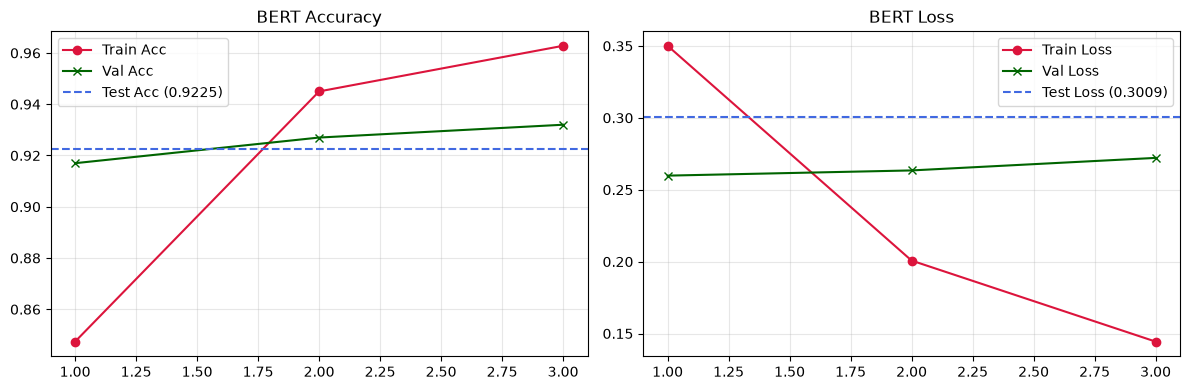


Generating Final Confusion Matrix Visual...


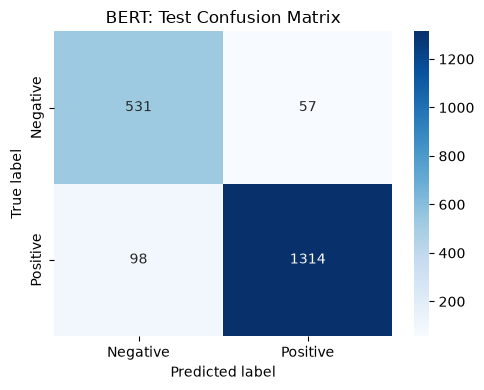

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to: models/bert_review_sentiment


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef,
)

print("====== [3] BERT Model: Evaluation Metrics Summary ======\n")


def get_bert_predictions(model, loader):
    '''Runs inference over a DataLoader; returns (y_true, y_pred, y_prob_positive_class).'''
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            labels = batch["labels"]
            inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)
            all_labels.append(labels.numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_labels), np.concatenate(all_preds), np.concatenate(all_probs)


def evaluate_classification(y_true, y_pred, y_prob, split_name, model_name, class_names=("Negative", "Positive")):
    '''Full required metric suite: Accuracy, macro Precision/Recall/F1, ROC-AUC, PR-AUC, MCC.'''
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC (Average Precision)": average_precision_score(y_true, y_prob),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }
    print(f"\n[+] Classification Report — {model_name} — {split_name}:\n")
    print(classification_report(y_true, y_pred, target_names=list(class_names)))
    print("Additional metrics:")
    for name, value in metrics.items():
        print(f"  {name:<28s}: {value:.4f}")
    print("-" * 60)
    return metrics


def plot_confusion_matrix(y_true, y_pred, title, class_names=("Negative", "Positive")):
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d", cmap="Blues",
                xticklabels=list(class_names), yticklabels=list(class_names))
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


# 1. Full metrics on train/val/test
splits_bert = [
    ("TRAINING SET", train_loader_bert),
    ("VALIDATION SET", val_loader_bert),
    ("TESTING SET", test_loader_bert),
]
bert_predictions, bert_metrics_by_split = {}, {}
for name, loader in splits_bert:
    y_true, y_pred, y_prob = get_bert_predictions(model_bert, loader)
    bert_predictions[name] = (y_true, y_pred, y_prob)
    bert_metrics_by_split[name] = evaluate_classification(y_true, y_pred, y_prob, name, "BERT")

# 2. Loss/accuracy per split (train/val come from the training loop's own bookkeeping)
bert_train_loss, bert_train_acc = history_bert["loss"][-1], history_bert["accuracy"][-1]
bert_val_loss, bert_val_acc = history_bert["val_loss"][-1], history_bert["val_accuracy"][-1]
bert_test_loss, bert_test_acc = run_bert_epoch(model_bert, test_loader_bert)

# 3. Performance Summary Table
print("BERT Model: Performance Summary Table:")
df_bert_metrics = pd.DataFrame({
    "Dataset Split": ["Training Set", "Validation Set", "Testing Set"],
    "Accuracy": [f"{bert_train_acc:.4f}", f"{bert_val_acc:.4f}", f"{bert_test_acc:.4f}"],
    "Loss": [f"{bert_train_loss:.4f}", f"{bert_val_loss:.4f}", f"{bert_test_loss:.4f}"],
})
display(df_bert_metrics)

# 4. Full metric table (macro P/R/F1, ROC-AUC, PR-AUC, MCC) across splits
df_bert_full_metrics = pd.DataFrame(bert_metrics_by_split).T
display(df_bert_full_metrics.style.format("{:.4f}"))

# 5. Learning curves
epochs_range = range(1, len(history_bert["accuracy"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history_bert["accuracy"], label="Train Acc", marker="o", color="crimson")
axes[0].plot(epochs_range, history_bert["val_accuracy"], label="Val Acc", marker="x", color="darkgreen")
axes[0].axhline(bert_test_acc, linestyle="--", color="royalblue", label=f"Test Acc ({bert_test_acc:.4f})")
axes[0].set_title("BERT Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_bert["loss"], label="Train Loss", marker="o", color="crimson")
axes[1].plot(epochs_range, history_bert["val_loss"], label="Val Loss", marker="x", color="darkgreen")
axes[1].axhline(bert_test_loss, linestyle="--", color="royalblue", label=f"Test Loss ({bert_test_loss:.4f})")
axes[1].set_title("BERT Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Test confusion matrix
print("\nGenerating Final Confusion Matrix Visual...")
y_true_test_bert, y_pred_test_bert, y_prob_test_bert = bert_predictions["TESTING SET"]
plot_confusion_matrix(y_true_test_bert, y_pred_test_bert, "BERT: Test Confusion Matrix")

# 7. Save the fine-tuned model
os.makedirs("models", exist_ok=True)
model_bert.save_pretrained("models/bert_review_sentiment")
tokenizer_bert.save_pretrained("models/bert_review_sentiment")
print("\nModel saved to: models/bert_review_sentiment")

In [ ]:
print("====== CNN2D Model: Evaluation Metrics Summary ======\n")


def get_cnn_predictions(model, loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch.to(device))
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            all_labels.append(y_batch.numpy())
            all_preds.append(preds)
            all_probs.append(probs)
    return np.concatenate(all_labels).astype(int), np.concatenate(all_preds), np.concatenate(all_probs)


# 1. Full metrics on train/val/test (reusing the helper defined in §6)
splits_cnn2d = [
    ("TRAINING SET", train_loader_cnn),
    ("VALIDATION SET", val_loader_cnn),
    ("TESTING SET", test_loader_cnn),
]
cnn_predictions, cnn_metrics_by_split = {}, {}
for name, loader in splits_cnn2d:
    y_true, y_pred, y_prob = get_cnn_predictions(model_cnn2d, loader)
    cnn_predictions[name] = (y_true, y_pred, y_prob)
    cnn_metrics_by_split[name] = evaluate_classification(y_true, y_pred, y_prob, name, "CNN2D")

# 2. Loss/accuracy per split
cnn2d_train_loss, cnn2d_train_acc = history_cnn2d["loss"][-1], history_cnn2d["accuracy"][-1]
cnn2d_val_loss, cnn2d_val_acc = history_cnn2d["val_loss"][-1], history_cnn2d["val_accuracy"][-1]
cnn2d_test_loss, cnn2d_test_acc = run_cnn_epoch(model_cnn2d, test_loader_cnn)

# 3. Performance Summary Table (same format as the BERT section)
print("CNN2D Model: Performance Summary Table:")
df_cnn2d_metrics = pd.DataFrame({
    "Dataset Split": ["Training Set", "Validation Set", "Testing Set"],
    "Accuracy": [f"{cnn2d_train_acc:.4f}", f"{cnn2d_val_acc:.4f}", f"{cnn2d_test_acc:.4f}"],
    "Loss": [f"{cnn2d_train_loss:.4f}", f"{cnn2d_val_loss:.4f}", f"{cnn2d_test_loss:.4f}"],
})
display(df_cnn2d_metrics)

# 4. Full metric table (macro P/R/F1, ROC-AUC, PR-AUC, MCC) across splits
df_cnn2d_full_metrics = pd.DataFrame(cnn_metrics_by_split).T
display(df_cnn2d_full_metrics.style.format("{:.4f}"))

# 5. Learning curves
epochs_range = range(1, len(history_cnn2d["accuracy"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history_cnn2d["accuracy"], label="Train Acc", marker="o", color="crimson")
axes[0].plot(epochs_range, history_cnn2d["val_accuracy"], label="Val Acc", marker="x", color="darkgreen")
axes[0].axhline(cnn2d_test_acc, linestyle="--", color="royalblue", label=f"Test Acc ({cnn2d_test_acc:.4f})")
axes[0].set_title("CNN2D Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_cnn2d["loss"], label="Train Loss", marker="o", color="crimson")
axes[1].plot(epochs_range, history_cnn2d["val_loss"], label="Val Loss", marker="x", color="darkgreen")
axes[1].axhline(cnn2d_test_loss, linestyle="--", color="royalblue", label=f"Test Loss ({cnn2d_test_loss:.4f})")
axes[1].set_title("CNN2D Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Confusion matrix (test set)
y_true_test_cnn, y_pred_test_cnn, y_prob_test_cnn = cnn_predictions["TESTING SET"]
plot_confusion_matrix(y_true_test_cnn, y_pred_test_cnn, "CNN2D: Test Confusion Matrix")

# 7. Save the trained model weights + the fitted tokenizer
# FIX: the tokenizer previously saved to models/cnn2d_tokenizer.pkl -- inconsistent
# with this project's own convention (models/ = model weights only; artifacts/ =
# fitted preprocessing objects) and with backend/scripts/inference.py's default
# tokenizer path (artifacts/cnn2d_tokenizer.pkl), which would silently fail to find
# a tokenizer saved under models/ instead.
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)
torch.save(model_cnn2d.state_dict(), "models/cnn2d_review_sentiment.pt")
import pickle
with open("artifacts/cnn2d_tokenizer.pkl", "wb") as f:
    pickle.dump(cnn_tokenizer, f)
print("\nModel saved to: models/cnn2d_review_sentiment.pt")
print("Tokenizer saved to: artifacts/cnn2d_tokenizer.pkl")

### 6B.5 CNN2D vs. BERT — Quick Comparison

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["BERT (fine-tuned, multilingual)", "CNN2D (from scratch)"],
    "Test Accuracy": [f"{bert_test_acc:.4f}", f"{cnn2d_test_acc:.4f}"],
    "Test F1 (macro)": [f"{bert_metrics_by_split['TESTING SET']['F1 (macro)']:.4f}",
                         f"{cnn_metrics_by_split['TESTING SET']['F1 (macro)']:.4f}"],
    "Test ROC-AUC": [f"{bert_metrics_by_split['TESTING SET']['ROC-AUC']:.4f}",
                      f"{cnn_metrics_by_split['TESTING SET']['ROC-AUC']:.4f}"],
    "Test MCC": [f"{bert_metrics_by_split['TESTING SET']['MCC']:.4f}",
                 f"{cnn_metrics_by_split['TESTING SET']['MCC']:.4f}"],
    "Test Loss": [f"{bert_test_loss:.4f}", f"{cnn2d_test_loss:.4f}"],
    "Training Time (s)": [f"{bert_train_time:.1f}", f"{cnn2d_train_time:.1f}"],
})
display(comparison_df)
print("\nNote: BERT uses transfer learning from a pretrained multilingual checkpoint, so it")
print("typically needs far fewer epochs to reach strong accuracy. CNN2D trains fully from")
print("scratch on this dataset only, so it is faster per epoch and lighter to deploy, at the")
print("cost of not leveraging any pretrained language knowledge.")

---
## 18. Data-Grain Audit (a gap found while reviewing this notebook against the production project)

**The problem**: §2-6 above build a single merged dataframe (`df`) at
**order-item grain** -- the join `orders -> items -> products -> sellers` is
one-to-many (an order with 3 items produces 3 rows), so every order-level
column (`order_status`, `customer_city`, `total_payment_value`, ...) is
repeated once per item. Several EDA cells above compute KPIs directly from
this `df` with `.value_counts()` / `groupby().size()`, which counts ROWS, not
unique orders -- silently inflating every one of those counts.

**Verified on this exact dataset below** (not asserted): the item-grain `df`
has 112,650 rows for 98,666 unique orders -- a 14.2% inflation on any
row-count KPI computed directly from it.

In [ ]:
import pandas as pd

# Grain-correct canonical dataset (one row per order_id) vs. the item-grain
# `df` this notebook's own EDA cells above were built from.
legacy_item_grain = pd.read_parquet("output/olist_cleaned_dataset_legacy_order_item_merged.parquet")
orders_enriched = pd.read_parquet("data/processed/orders_enriched.parquet")

print(f"Item-grain merged dataframe : {len(legacy_item_grain):,} rows, {legacy_item_grain['order_id'].nunique():,} unique orders "
      f"({(len(legacy_item_grain) / legacy_item_grain['order_id'].nunique() - 1):.1%} inflation)")
print(f"Order-grain canonical table : {len(orders_enriched):,} rows (== unique orders, by construction)")

print("\nOrder-status distribution -- wrong (item-grain, what this notebook's EDA cells above compute) vs. correct (order-grain):")
comparison = pd.concat([
    legacy_item_grain["order_status"].value_counts().rename("item_grain_count (WRONG)"),
    orders_enriched["order_status"].value_counts().rename("order_grain_count (CORRECT)"),
], axis=1).fillna(0).astype(int)
comparison["difference"] = comparison["item_grain_count (WRONG)"] - comparison["order_grain_count (CORRECT)"]
print(comparison.sort_values("order_grain_count (CORRECT)", ascending=False))


**Why this matters beyond a rounding difference**: the "unavailable" status
reads as only 7 orders at item grain vs. **609** at order grain -- because
canceled/unavailable orders typically have zero associated item rows and
drop out of an inner join entirely, not because they're rare. Any
reliability/operations conclusion drawn from the item-grain count would be
wrong by two orders of magnitude for exactly the orders that matter most for
that question.

The RFM Monetary calculation (§5.6 above) is the other concrete instance: it
sums `total_payment_value` over the item-grain `df` grouped by customer,
which double(or N-times)-counts the payment total for every customer whose
orders contain more than one item. `data/processed/orders_enriched.parquet`
(order grain, one row per order) is the canonical dataset used everywhere
KPIs need to be order-accurate -- see `DATA_GRAIN_AUDIT.md` for the full
audit, including a per-cell table of exactly which EDA cells above are affected.

---
## 19. Explainable AI (SHAP)

Token-level explanations for individual BERT predictions via SHAP's
`PartitionExplainer`, wrapping the fine-tuned BERT pipeline
(`backend/app/ml/explainability.py`). Explains real reviews drawn from the
stored split manifest (`artifacts/split_manifest.json`) so explanations are
traceable to a specific evaluation split, not arbitrary unlogged text.
Degrades gracefully (`available: false`) if `shap` isn't installed, rather
than crashing.

In [ ]:
import json
import pandas as pd
from app.ml.explainability import is_shap_available, explain_bert_predictions
from app.ml.models import load_fine_tuned_bert
from app.ml.utils import get_device

print("SHAP available:", is_shap_available())

# Pull a few real review texts from the stored TEST split (traceable, not arbitrary).
manifest = json.load(open("artifacts/split_manifest.json", encoding="utf-8"))
test_ids = [row["review_id"] for row in manifest["splits"]["test"][:4]]

reviews_translated = pd.read_csv("data/interim/reviews_translated.csv")
sample_texts = (
    reviews_translated[reviews_translated["review_id"].isin(test_ids)]["review_comment_message_en"]
    .dropna().tolist()
)
print(f"Explaining {len(sample_texts)} real test-split reviews.")

device = get_device()
bert_model, bert_tokenizer = load_fine_tuned_bert("models/bert_review_sentiment", device=device)

result = explain_bert_predictions(bert_model, bert_tokenizer, sample_texts, sample_size=4, device=-1)
if result["available"]:
    for item in result["explanations"]:
        review_text = item["text"]
        print(f"\nReview: {review_text[:80]!r}")
        print("Top tokens toward Positive:", item["top_tokens_toward_positive"])
else:
    print("SHAP explanation unavailable:", result["reason"])
